# Imports

In [1]:
# Imports
import os
import sys
import gc
sys.path.append('../src/utils')
sys.path.append('../src')
import numpy as np
from torch.utils.data import Dataset
from tqdm import tqdm
import h5py
import joblib
import torch
import fvdb.nn as fvnn
import mesh_tools as mt
from models import unet as unetModels
import matplotlib.pyplot as plt

import igl
import fvdb
from meshplot import plot

# Utils

In [2]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'

def count_parameters(model, print_result=True):
    num = sum(p.numel() for p in model.parameters() if p.requires_grad)
    if print_result:
        if num > 1e6:
            print("The model has {:.1f}M parameters".format(num/1000000))
        elif num > 1000:
            print("The model has {:.1f}k parameters".format(num/1000))
        return
    return num

def vdb_marching_cubes(out: fvnn.VDBTensor):
    '''computes marching cubes for a VDBTensor'''
    nv, nf, _ = out.grid.marching_cubes(out.data)
    return nv.jdata.cpu().detach().numpy(), nf.jdata.cpu().detach().numpy()

def plot_vdb(out: fvnn.VDBTensor):
    '''plots a VDBTensor using mesh_tools'''
    nv, nf = vdb_marching_cubes(out)
    plot(nv, nf)

def fetch_numpy_values(grid: fvdb.GridBatch, arr: np.array, size:int):
    '''fetches values from a numpy array based on the ijk indices in the grid'''
    # ijk = grid.ijk.jdata.cpu().detach().numpy()+(size-1)//2
    ijk = grid.ijk.jdata.cpu().detach().numpy()
    
    if max(ijk[:, 0]) >= arr.shape[0] or max(ijk[:, 1]) >= arr.shape[1] or max(ijk[:, 2]) >= arr.shape[2]:
        # If indices are out of bounds, we can add the maximum value to the indices
        ijk = np.clip(ijk, 0, np.array(arr.shape) - 1)
        # print(f"Indices out of bounds. Clipping to max shape: {arr.shape}")
    
    values = arr[ijk[:, 0], ijk[:, 1], ijk[:, 2]]
    return torch.tensor(values, dtype=torch.float32, device=grid.device)

def scaled_sdf(sdf_arr: np.array, sdf_scaling_value: int):
    '''scales the SDF array by the threshold value'''
    return (sdf_scaling_value-1)*sdf_arr[:, None]

def sdf_to_vdb(sdf_arr: np.array, 
                mask: np.array, 
                size=33):

    '''Converts a SDF array to a VDBTensor with a given size and mask.'''
    sdf_scaling_value = (size-1)*2 + 1

    #  create a grid of the size without nomalize actual shape
    ijk_mesh_grid = mt.mesh_grid(size)
    ijk_mesh_grid = ijk_mesh_grid.reshape(size, size, size, 3)
    
    ijk = torch.tensor(ijk_mesh_grid[mask], 
                        dtype=torch.int, 
                        device=device)
    grid = fvdb.gridbatch_from_ijk(fvdb.JaggedTensor(ijk), 
                                    voxel_sizes=(1/(size-1)), 
                                    origins=torch.tensor([0, 0, 0], 
                                    device=device))
    
    sdf_values = fetch_numpy_values(grid, sdf_arr, size)
    sdf_values = scaled_sdf(sdf_values, sdf_scaling_value)
    return fvnn.VDBTensor(grid, grid.jagged_like(sdf_values))

def sdf_from_mesh(mesh_path: str, grid_n: int):
    '''Generates SDF from a mesh file using igl signed distance.'''
    v, f = igl.read_triangle_mesh(mesh_path)
    v = 2*mt.NDCnormalize(v)
    points = mt.mesh_grid(grid_n, True)
    sdf = igl.signed_distance(points, v, f)[0].reshape(grid_n, grid_n, grid_n)/2
    return sdf

# Params

`We will convert objs mesh to sdf at different resolution`

In [3]:
path = '../run/data/model_weights.pth'
gt_dir = '../../data/GT_thingi'
file_names = os.listdir(gt_dir)[:1]
file_names = ['64764.obj']
dataset_grids = [33] # [33, 65, 129] we can test on multiple grids
upsample_factors = {129:4, 65: 4, 33:4} # upsample 65 to 257

In [4]:
file_names

['64764.obj']

# Load Model

In [5]:
model = unetModels.FVDBUNetBase(
                in_channels=4,
                out_channels=1)

# load the trained model
model.load_state_dict(torch.load(path))
model = model.to('cuda' if torch.cuda.is_available() else 'cpu')

/tmp/ipykernel_4099255/2832388839.py:6: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(path))


`Parameters`

In [6]:
count_parameters(model)

The model has 21.7M parameters


# Prepare Dataset

need to change the way how we calculate the SDF, just change: `sdf_from_mesh`

In [7]:
class Dataset(Dataset):
    def __init__(self, 
                 src_dir,
                 names_set,
                 dataset_grids,
                 upsample_factors):
        
        self.input_dir = src_dir
        self.names_set = names_set
        self.dataset_grids = dataset_grids
        self.mask_threshold = {grid_size: (grid_size)*2+1 for grid_size in dataset_grids}
        self.upsample_factors = upsample_factors

        # stepup to read the dataset
        self._read_dataset()  # This will run setup() and read the files in parallel

    def _get_all_shifted_positions(self, vdb_tensor, size, upsample_factor):
        mfg = torch.tensor(mt.mesh_grid(upsample_factor+1), device=vdb_tensor.device) - (upsample_factor//2)
        new_ijks = []
        new_features = []
        for mg in mfg:
            org_ijk = vdb_tensor.grid.ijk.jdata
            ijk = (upsample_factor * org_ijk + mg).view(-1, 3)
            ijk = np.clip(ijk.cpu().detach().numpy(), 0, (size-1)*upsample_factor)
            ijk_vector = ijk - (org_ijk.cpu().detach().numpy() * upsample_factor)
            ijk_vector = ijk_vector / (upsample_factor // 2)  # Normalize to values between -1 and 1
            ijk_vector = torch.tensor(ijk_vector, dtype=torch.float32, device=vdb_tensor.device)

            new_features.append(torch.cat([vdb_tensor.data.jdata, ijk_vector], axis=-1))
            new_ijks.append(torch.tensor(ijk, dtype=torch.int, device=vdb_tensor.device))
        return new_features, new_ijks
    
    def _get_item(self, obj_name):
        '''Read the SDF in h5 file.'''

        sdf_dict = {}
        path = os.path.join(self.input_dir, obj_name)
        
        # fetch the SDF and output SDF
        sdf_dict['obj_name'] = obj_name
        for grid_size in self.dataset_grids:
            print('computing sdf of size ', grid_size)
            sdf_dict[grid_size] = sdf_from_mesh(path, grid_size)
        
        return sdf_dict

    def _read_dataset(self):
        out = joblib.Parallel(n_jobs=-1)(joblib.delayed(self._get_item)
                                                (obj_name) for obj_name in tqdm(self.names_set))

        # mask SDFs 
        self.masks = {}
        for grid_size in self.dataset_grids:
            self.masks[grid_size] = [mt.make_mask_close(_dict[grid_size], self.mask_threshold[grid_size])  for _dict in out]
        self.out = out

    def _get_vdb_from_sdf(self, index):
        for _input_size in self.dataset_grids:
            if self.upsample_factors[_input_size] not in [2, 4]:
                Warning("Model only trained for upsample factors of 2 and 4 ....")
        
        _dict = self.out[index]

        # create a set to hold the vdb tensors
        output_set = []
        output_set.append([_dict['obj_name'] for _ in range(len(self.dataset_grids))])
        output_set.append(self.dataset_grids)

        # create a mask for the test set
        vdb_tensors = []
        new_featuress = []
        for grid_size in self.dataset_grids:
            input_size = grid_size
            input_sdf = _dict[input_size]
            mask = self.masks[input_size][index]
            self.upsample_factor = self.upsample_factors[grid_size]
            vdb_tensor = sdf_to_vdb(
                                        sdf_arr=input_sdf,
                                        mask=mask,
                                        size=input_size, #33
                                    )

            new_features, _ = self._get_all_shifted_positions(vdb_tensor, 
                                            size=input_size, 
                                            upsample_factor=self.upsample_factor)
            vdb_tensors.append(vdb_tensor)
            new_featuress.append(new_features)

        output_set.append(vdb_tensors)
        output_set.append(new_featuress)
        return tuple(output_set)

    def __len__(self):
        return len(self.out)
    
    def __getitem__(self, index):
        return self._get_vdb_from_sdf(index)


class DataLoader():
    def __init__(self, 
                 input_dir, 
                 dataset_grids,
                 upsample_factors):
        self.input_dir = input_dir
        self.dataset_grids = dataset_grids
        self.upsample_factors = upsample_factors
        
    @staticmethod
    def custom_collate_fn_test(batch):
        # batch is a list of tuples: [(vdb_tensor, new_ijks, new_features), ...]
        obj_names, input_sizes, vdb_tensors, new_featuress = zip(*batch)
        obj_names = obj_names[0]
        input_sizes = input_sizes[0]
        vdb_tensors = vdb_tensors[0]
        new_featuress = new_featuress[0]
        
        output = []
        for index in range(len(obj_names)):
            output.append((obj_names[index],
                           input_sizes[index],
                           vdb_tensors[index],
                           new_featuress[index]))
        return output

    def get(self, names_set):
        test_set = names_set

        dataset = Dataset(
                        src_dir=self.input_dir,
                        names_set=test_set,
                        dataset_grids=self.dataset_grids,
                        upsample_factors=self.upsample_factors
                    )
        
        dataloader = torch.utils.data.DataLoader(dataset,
                                            collate_fn=self.custom_collate_fn_test,
                                            batch_size=1,  # Test loader usually has batch size of 1
                                            shuffle=False)
        return dataloader

# Prediction

In [8]:
import time

def predict(sdf_scaling, 
                input_size,
                upsample_factor,
                input_vdb, 
                new_features, 
                model):

    all_inputs = []
    for feature in new_features:
        all_inputs.append(fvnn.VDBTensor(input_vdb.grid,
                                        input_vdb.grid.jagged_like(feature)))

    upsampled_sdf_size = ((input_size - 1) * upsample_factor) + 1
    sdf = np.full((upsampled_sdf_size, 
                    upsampled_sdf_size, 
                    upsampled_sdf_size), 100.0)
        
    BATCH_SIZE = 20
    num_samples = len(all_inputs)

    pred_values_list = []
    pred_ijk_list = []
    vector_list = []

    for start in range(0, num_samples, BATCH_SIZE):
        end = min(start + BATCH_SIZE, num_samples)
        batch_vdb = fvdb.jcat(all_inputs[start:end])
        vector_list.append(batch_vdb.jdata[:, 1:4].cpu().detach().numpy())
        batch_vdb = batch_vdb.cuda()
        batch_pred = model(batch_vdb)
        pred_values_list.append(batch_pred.jdata.detach().cpu().numpy().squeeze())
        pred_ijk_list.append(batch_pred.grid.ijk.jdata.cpu().detach().numpy())

    pred_values = np.concatenate(pred_values_list, axis=0)
    pred_ijk = np.concatenate(pred_ijk_list, axis=0)
    vector = np.concatenate(vector_list, axis=0)
    pred_ijk = (pred_ijk)*upsample_factor + (vector*(upsample_factor//2)).astype(int)
    
    # means predictions
    D, H, W = sdf.shape
    flat_idx = np.ravel_multi_index(pred_ijk.T, sdf.shape)  # (N,)

    sum_arr = np.zeros(sdf.size, dtype=np.float32)
    cnt_arr = np.zeros(sdf.size, dtype=np.int64)

    np.add.at(sum_arr, flat_idx, pred_values)     # accumulate sums per voxel
    np.add.at(cnt_arr, flat_idx, 1)               # accumulate counts per voxel

    mask = cnt_arr > 0
    mean_arr = np.zeros_like(sum_arr, dtype=np.float32)
    mean_arr[mask] = sum_arr[mask] / cnt_arr[mask]

    sdf.flat[mask] = mean_arr[mask] 

    sdf_mask = np.abs(sdf) < 100
       
    # create a fvdb tensor from the sdf
    up_ijk = fvdb.JaggedTensor(torch.tensor(np.array(np.where(sdf_mask)).T))
    up_grid = fvdb.gridbatch_from_ijk(
            up_ijk,
            voxel_sizes=(1/(upsampled_sdf_size-1)),
            origins=torch.tensor([0, 0, 0])
        )
    up_ijk = up_grid.ijk.jdata.cpu().detach().numpy()
    up_values = sdf[up_ijk[:, 0], up_ijk[:, 1], up_ijk[:, 2]]
    # descale the sdf values
    up_values = up_values * (1/(sdf_scaling-1))
    up_tensor = fvnn.VDBTensor(up_grid,
                                up_grid.jagged_like(torch.tensor(up_values)))
    return up_tensor


def get_predictions(test_loader, 
                     upsample_factor_dict,
                     model):

    # model on device
    device = 'cuda' if torch.cuda.is_available() else 'cpu'
    model.to(device)
    model.eval()
    predictions_dict = {}

    with torch.no_grad():
        for batch in tqdm(test_loader, desc='Testing'):
            for mini_batch in batch:
                
                (obj_name, input_size, vdb_inputs, new_features) = mini_batch 
                sdf_scaling_value = (input_size-1)*2+1
                upsample_factor = upsample_factor_dict[input_size]
                vdb_inputs = fvdb.jcat(vdb_inputs)
                vdb_inputs = vdb_inputs.cuda()
                
                torch.cuda.empty_cache()
                gc.collect()
                t0 = time.time()
                # predictions
                vdb_up_tensor = predict(sdf_scaling_value,
                                                        input_size,
                                                        upsample_factor,
                                                        vdb_inputs, 
                                                        new_features,  
                                                        model)
                print(time.time() - t0)
                predictions_dict[obj_name] = {input_size: vdb_up_tensor}  
    return predictions_dict

In [9]:
dataloader = DataLoader(input_dir=gt_dir, 
                            dataset_grids=dataset_grids,
                            upsample_factors=upsample_factors)
dataloader = dataloader.get(names_set=file_names)


100%|██████████| 1/1 [00:00<00:00, 28.50it/s]


computing sdf of size  33


  o ./models_NDC_norm/GT_thingi/64764.obj 


In [37]:
obj_names, input_sizes, vdb_tensors, new_features = next(iter(dataloader))[0]
all_inputs = []
# for feature in new_features:
for i in [0, 4, 10, 12, 14, 20, 22, 24]:
    all_inputs.append(fvnn.VDBTensor(vdb_tensors.grid,
                                    vdb_tensors.grid.jagged_like(new_features[i])))

In [38]:
def encode(self, x):
    out = self.conv0p1s1(x)
    out = self.bn0(out)
    out_p1 = self.relu(out)
    grid1 = out_p1.grid

    out = self.conv1p1s2(out_p1)
    out = self.bn1(out)
    out = self.relu(out)
    out_b1p2 = self.block1(out)
    grid2 = out_b1p2.grid

    out = self.conv2p2s2(out_b1p2)
    out = self.bn2(out)
    out = self.relu(out)
    out_b2p4 = self.block2(out)
    grid4 = out_b2p4.grid
    

    out = self.conv3p4s2(out_b2p4)
    out = self.bn3(out)
    out = self.relu(out)
    out_b3p8 = self.block3(out)
    grid8 = out_b3p8.grid

    # tensor_stride=16
    out = self.conv4p8s2(out_b3p8)
    out = self.bn4(out)
    out = self.relu(out)
    out = self.block4(out)
    

    # tensor_stride=8
    out = self.convtr4p16s2(out, out_grid=grid8)
    out = self.bntr4(out)
    out = self.relu(out)

    out = fvdb.jcat([out, out_b3p8], dim=1)
    out = self.block5(out)

    # tensor_stride=4
    out = self.convtr5p8s2(out, out_grid=grid4)
    out = self.bntr5(out)
    out = self.relu(out)

    out = fvdb.jcat([out, out_b2p4], dim=1)
    out = self.block6(out)

    # tensor_stride=2
    out = self.convtr6p4s2(out, out_grid=grid2)
    out = self.bntr6(out)
    out = self.relu(out)

    out = fvdb.jcat([out, out_b1p2], dim=1)
    out = self.block7(out)
    

    # tensor_stride=1
    out = self.convtr7p2s2(out, out_grid=grid1)
    out = self.bntr7(out)
    out = self.relu(out)

    out = fvdb.jcat([out, out_p1], dim=1)
    out = self.block8(out)
    return out

In [99]:
outs = []
with torch.no_grad():
    for a in all_inputs:
        outs.append(encode(model, a))
    # out = encode(model, a)
out = fvdb.jcat(outs, dim=-1)

In [100]:
from torch_pca import PCA

In [101]:
all_inputs[0].jdata[:, 0].abs()<1

tensor([False, False, False,  ..., False, False, False], device='cuda:0')

In [102]:
out_feat = torch.zeros((dataset_grids[0], dataset_grids[0], dataset_grids[0], out.jdata.shape[1]), device=out.device)
out_feat[*out.ijk.jdata.T] = out.jdata 
res = PCA(3).fit_transform(out_feat.reshape(-1, torch.tensor(out_feat.shape[-1])))
res = (res-res.min(dim=0).values)/(res.max(dim=0).values-res.min(dim=0).values)
res = res.view(dataset_grids[0], dataset_grids[0], dataset_grids[0], 3)


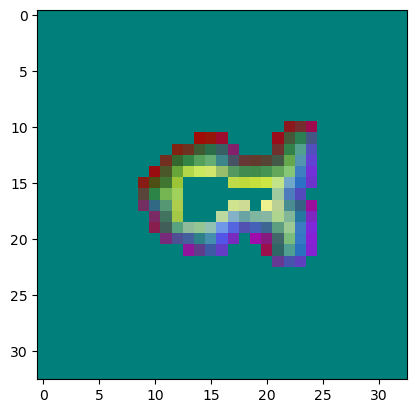

In [103]:
slice = res[:, :, 20]
# slice = (slice - slice.min(dim=0, keepdim=True).values) / (slice.max(dim=0, keepdim=False).values - slice.min(dim=0, keepdim=False).values)
plt.imshow(slice.cpu().detach().numpy())

In [96]:
mask = all_inputs[0].jdata[:, 0].abs()<1
ijks = out.grid.ijk.jdata[mask]
new_grid = fvdb.gridbatch_from_ijk(ijks)
new_tensor = fvnn.VDBTensor(new_grid, new_grid.jagged_like(out.jdata[mask]))
new_data = new_tensor.data.jdata
new_data = PCA(3).fit_transform(new_data)
new_data = (new_data-new_data.min(0).values)/(new_data.max(0).values-new_data.min(0).values)

In [97]:
import trimesh
def grid_to_mesh(grid, output_edges=False, colors=None):
    '''colors: num_voxelsx3 np.array'''
    cube_mesh = trimesh.creation.box()
    cube_v = torch.tensor(cube_mesh.vertices, device=grid.device)[
        None, :]*grid.voxel_sizes
    cube_f = torch.tensor(cube_mesh.faces, device=grid.device)[None, :]
    if output_edges:
        cube_f = torch.tensor([[
            [0, 1], [0, 4], [0, 2], [1, 3], [1, 5], [4, 5],
            [5, 7], [4, 6], [7, 6], [2, 6], [2, 3], [3, 7]]],
            device=grid.device)
    points = grid.grid_to_world(grid.ijk.float()).jdata

    cube_v = cube_v.expand(len(points), *cube_v.shape[1:]).clone()
    cube_f = cube_f.expand(len(points), *cube_f.shape[1:]).clone()
    num = torch.arange(len(points), device=grid.device)
    cube_f += num[:, None, None]*cube_v.shape[1]
    cube_v += points[:, None, :]
    cube_v = cube_v.view(-1, cube_v.shape[-1]).cpu().detach().numpy()
    cube_f = cube_f.view(-1, cube_f.shape[-1]).cpu().detach().numpy()

    if colors is not None:
        colors = np.repeat(colors, len(cube_mesh.vertices), 0)
        return cube_v, cube_f, colors
    return cube_v, cube_f


In [98]:
plot(*grid_to_mesh(new_tensor.grid, colors=new_data.cpu().detach().numpy()))

Renderer(camera=PerspectiveCamera(children=(DirectionalLight(color='white', intensity=0.6, position=(16.0, 16.…